ORANGE — KEY WAVELENGTH INTENSITIES (normalized)
Sample         I545       I684       I737
------------------------------------------------
O1         0.002108   0.003663   0.002881
O2         0.002159   0.003396   0.002645
O3         0.002356   0.002430   0.002192

ORANGE — SPECTRAL RATIOS
Sample       I684/I545$      I684/I737(I684+I737)/I545
--------------------------------------------------------------------
O1               1.7378         1.2712         3.1050         0.0021
O2               1.5727         1.2840         2.7975         0.0022
O3               1.0313         1.1084         1.9617         0.0024

Expected trend (O1=unripe -> O3=ripe):
  I684/I545      -> decreases
  I684/I737      -> increases
  (684+737)/545  -> decreases
  I590/I545      -> stays low (carotenoid dominant in orange)


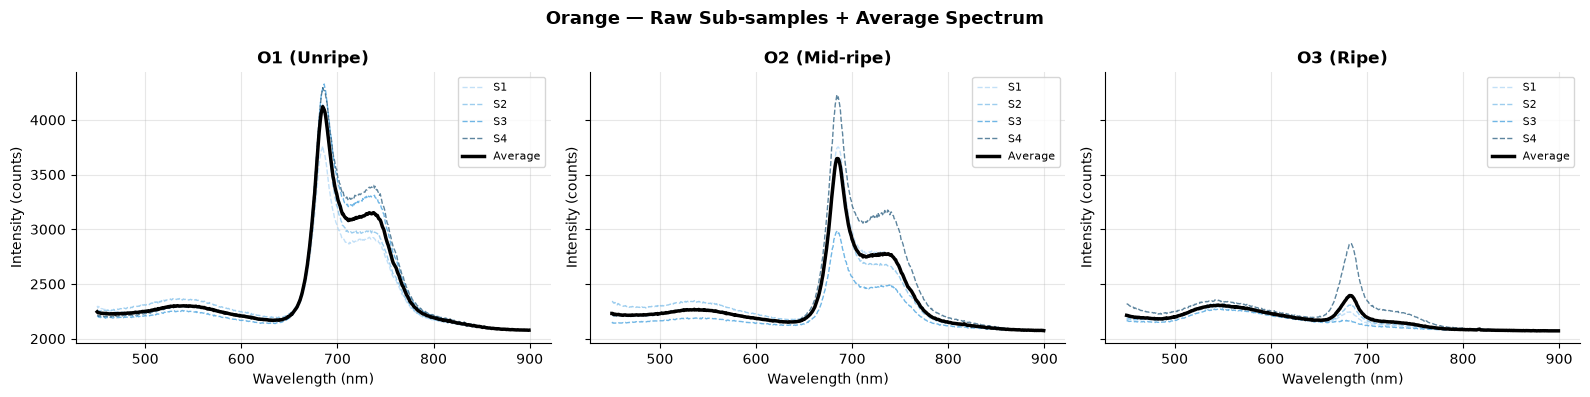

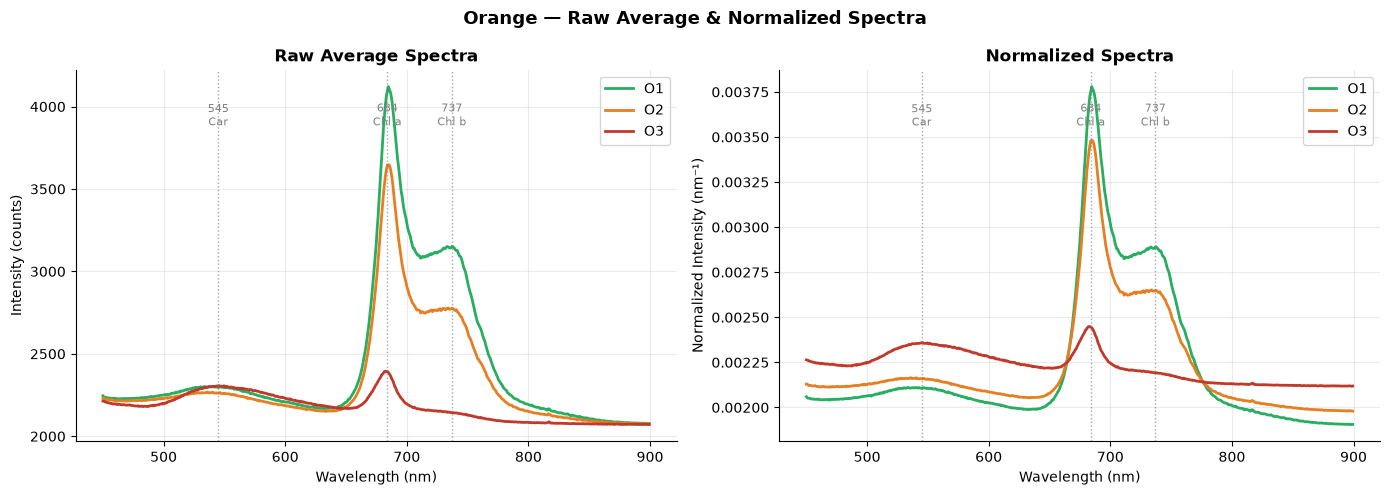

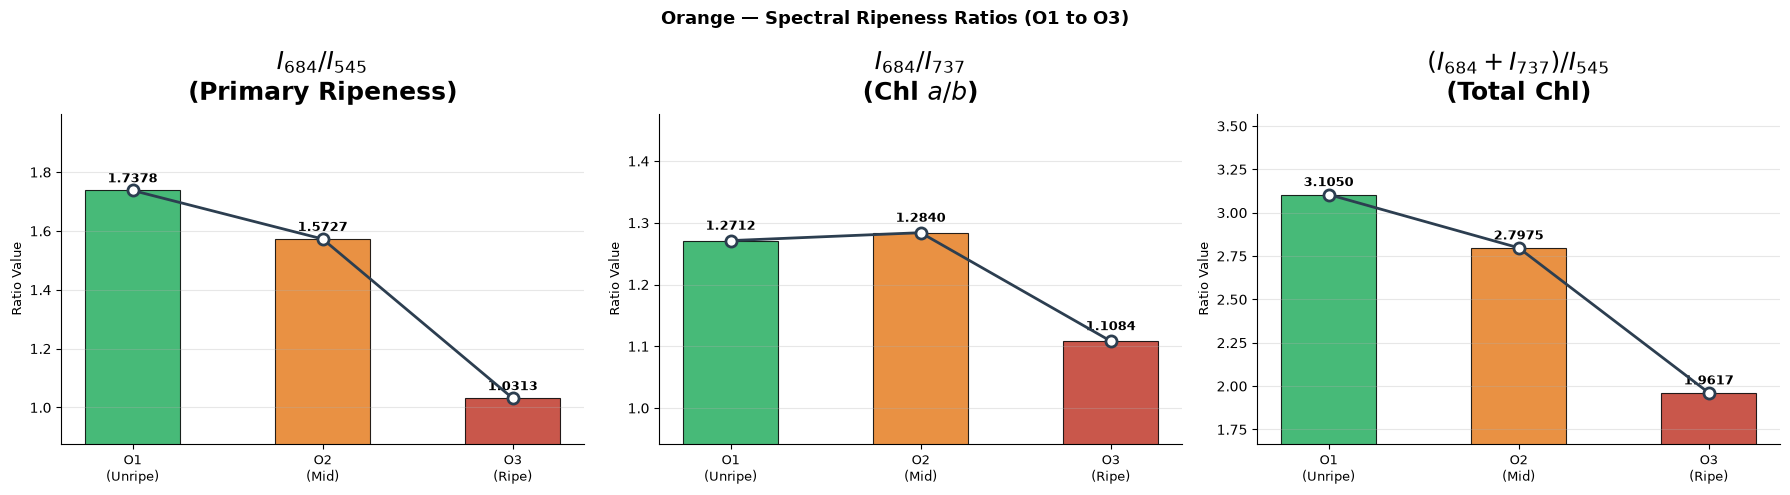

In [1]:
"""
=============================================================================
ORANGE SPECTRAL RATIO ANALYSIS
4 Ratios: I684/I545 | I684/I737 | (I684+I737)/I545 | I590/I545
Samples: O1, O2, O3 (each averaged from 4 sub-samples)
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# =============================================================================
# SECTION 1: FILE PATHS
# =============================================================================

O1_files = [
    r"Data\Orange\SpectralData_Orange\O1_S1.txt",
    r"Data\Orange\SpectralData_Orange\O1_S2.txt",
    r"Data\Orange\SpectralData_Orange\O1_S3.txt",
    r"Data\Orange\SpectralData_Orange\O1_S4.txt",
]

O2_files = [
    r"Data\Orange\SpectralData_Orange\O2_S1.txt",
    r"Data\Orange\SpectralData_Orange\O2_S2.txt",
    r"Data\Orange\SpectralData_Orange\O2_S3.txt",
    r"Data\Orange\SpectralData_Orange\O2_S4.txt",
]

O3_files = [
    r"Data\Orange\SpectralData_Orange\O3_S1.txt",
    r"Data\Orange\SpectralData_Orange\O3_S2.txt",
    r"Data\Orange\SpectralData_Orange\O3_S3.txt",
    r"Data\Orange\SpectralData_Orange\O3_S4.txt",
]


# =============================================================================
# SECTION 2: LOAD + AVERAGE
# =============================================================================

def load_and_average(file_list, wl_min=450, wl_max=900):
    """Load 4 sub-sample files, filter wavelength range, return avg spectrum."""
    datasets    = [np.loadtxt(f) for f in file_list]
    wavelength  = datasets[0][:, 0]
    intensities = np.array([d[:, 1] for d in datasets])

    mask        = (wavelength >= wl_min) & (wavelength <= wl_max)
    wavelength  = wavelength[mask]
    intensities = intensities[:, mask]
    I_avg       = np.mean(intensities, axis=0)

    return wavelength, intensities, I_avg


wavelength, O1_subs, I_avg_1 = load_and_average(O1_files)
_,          O2_subs, I_avg_2 = load_and_average(O2_files)
_,          O3_subs, I_avg_3 = load_and_average(O3_files)


# =============================================================================
# SECTION 3: NORMALIZATION ONLY (peak + area)
# =============================================================================

def normalize(I, wl):
    """Peak normalization then area normalization → units: nm⁻¹"""
    I_peak = I / np.max(I)
    return I_peak / trapezoid(I_peak, wl)


I_norm_1 = normalize(I_avg_1, wavelength)
I_norm_2 = normalize(I_avg_2, wavelength)
I_norm_3 = normalize(I_avg_3, wavelength)


# =============================================================================
# SECTION 4: INTENSITY AT WAVELENGTH (±5 nm window)
# =============================================================================

def get_I(spectrum, wl_array, target, window=5):
    """Mean intensity over ±window nm around target wavelength."""
    mask = (wl_array >= target - window) & (wl_array <= target + window)
    return np.mean(spectrum[mask])


# =============================================================================
# SECTION 5: CALCULATE 4 RATIOS  (on normalized spectra)
# =============================================================================

def compute_ratios(spectrum, wl):
    I545 = get_I(spectrum, wl, 545)
    
    I684 = get_I(spectrum, wl, 684)
    I737 = get_I(spectrum, wl, 737)

    r1 = I684 / I545               # Primary ripeness
    r2 = I684 / I737               # Chl a/b
    r3 = (I684 + I737) / I545      # Total Chl
                   

    return r1, r2, r3, I545, I684, I737


R_O1 = compute_ratios(I_norm_1, wavelength)
R_O2 = compute_ratios(I_norm_2, wavelength)
R_O3 = compute_ratios(I_norm_3, wavelength)

ratio_names = [
    r'$I_{684}/I_{545}$' '\n(Primary Ripeness)',
    r'$I_{684}/I_{737}$' '\n(Chl $a/b$)',
    r'$(I_{684}+I_{737})/I_{545}$' '\n(Total Chl)',
    r'$I_{590}/I_{545}$' '\n(Carotenoid-related)',
]
ratios = {
    'O1': R_O1[:4],
    'O2': R_O2[:4],
    'O3': R_O3[:4],
}


# =============================================================================
# SECTION 6: PRINT RESULTS
# =============================================================================

print("=" * 60)
print("ORANGE — KEY WAVELENGTH INTENSITIES (normalized)")
print("=" * 60)
print(f"{'Sample':<8} {'I545':>10} {'I684':>10} {'I737':>10}")
print("-" * 48)
for name, R in zip(['O1', 'O2', 'O3'], [R_O1, R_O2, R_O3]):
    print(f"{name:<8} {R[3]:>10.6f} {R[4]:>10.6f} {R[5]:>10.6f}")

print("\n" + "=" * 60)
print("ORANGE — SPECTRAL RATIOS")
print("=" * 60)
headers = ['I684/I545$', 'I684/I737', '(I684+I737)/I545']
print(f"{'Sample':<8}", end="")
for h in headers:
    print(f"{h:>15}", end="")
print()
print("-" * 68)
for name, R in zip(['O1', 'O2', 'O3'], [R_O1, R_O2, R_O3]):
    print(f"{name:<8}", end="")
    for v in R[:4]:
        print(f"{v:>15.4f}", end="")
    print()

print("\nExpected trend (O1=unripe -> O3=ripe):")
print("  I684/I545      -> decreases")
print("  I684/I737      -> increases")
print("  (684+737)/545  -> decreases")
print("  I590/I545      -> stays low (carotenoid dominant in orange)")


# =============================================================================
# SECTION 7: PLOT 1 — RAW SPECTRA (sub-samples + average)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle('Orange — Raw Sub-samples + Average Spectrum', fontsize=13, fontweight='bold')

sub_colors = ['#aad4f5', '#74b9e8', '#3498db', '#1a5276']

for ax, subs, I_avg, label in zip(
    axes,
    [O1_subs, O2_subs, O3_subs],
    [I_avg_1, I_avg_2, I_avg_3],
    ['O1 (Unripe)', 'O2 (Mid-ripe)', 'O3 (Ripe)']
):
    for i, sub in enumerate(subs):
        ax.plot(wavelength, sub, linestyle='--', color=sub_colors[i],
                linewidth=1, label=f'S{i+1}', alpha=0.7)
    ax.plot(wavelength, I_avg, 'k-', linewidth=2.5, label='Average')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Intensity (counts)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('orange_raw_spectra.png', dpi=600, bbox_inches='tight')
plt.show()


# =============================================================================
# SECTION 8: PLOT 2 — RAW AVERAGE + NORMALIZED COMPARISON
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Orange — Raw Average & Normalized Spectra', fontsize=13, fontweight='bold')

peak_wls  = [545, 684, 737]
peak_lbls = ['545\nCar',  '684\nChl a', '737\nChl b']
o_colors  = ['#27ae60', '#e67e22', '#c0392b']

for I, color, name in zip([I_avg_1, I_avg_2, I_avg_3], o_colors, ['O1', 'O2', 'O3']):
    ax1.plot(wavelength, I, color=color, linewidth=2, label=name)
for I, color, name in zip([I_norm_1, I_norm_2, I_norm_3], o_colors, ['O1', 'O2', 'O3']):
    ax2.plot(wavelength, I, color=color, linewidth=2, label=name)

for ax in [ax1, ax2]:
    for wl, lbl in zip(peak_wls, peak_lbls):
        ax.axvline(wl, color='gray', linestyle=':', linewidth=1, alpha=0.7)
        ax.text(wl, ax.get_ylim()[1] * 0.92, lbl, ha='center', fontsize=8, color='gray')
    ax.set_xlabel('Wavelength (nm)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.set_title('Raw Average Spectra', fontweight='bold')
ax1.set_ylabel('Intensity (counts)')
ax2.set_title('Normalized Spectra', fontweight='bold')
ax2.set_ylabel('Normalized Intensity (nm⁻¹)')

plt.tight_layout()
plt.savefig('orange_spectra_comparison.png', dpi=600, bbox_inches='tight')
plt.show()


# =============================================================================
# SECTION 9: PLOT 3 — RATIO BAR + LINE PLOTS
# =============================================================================

x      = np.array([1, 2, 3])
x_lbls = ['O1\n(Unripe)', 'O2\n(Mid)', 'O3\n(Ripe)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Orange — Spectral Ripeness Ratios (O1 to O3)', fontsize=13, fontweight='bold')

bar_colors  = ['#27ae60', '#e67e22', '#c0392b']
trend_color = '#2c3e50'

for idx, (ax, rname) in enumerate(zip(axes, ratio_names)):
    vals = [ratios['O1'][idx], ratios['O2'][idx], ratios['O3'][idx]]

    bars = ax.bar(x, vals, color=bar_colors, width=0.5,
                  alpha=0.85, edgecolor='black', linewidth=0.8)
    ax.plot(x, vals, 'o-', color=trend_color, linewidth=2,
            markersize=8, markerfacecolor='white', markeredgewidth=2, zorder=5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * max(vals),
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(rname, fontsize=18, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_lbls, fontsize=9)
    ax.set_ylabel('Ratio Value', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(min(vals) * 0.85, max(vals) * 1.15)

plt.tight_layout()
plt.savefig('orange_ratio_plots.png', dpi=600, bbox_inches='tight')
plt.show()